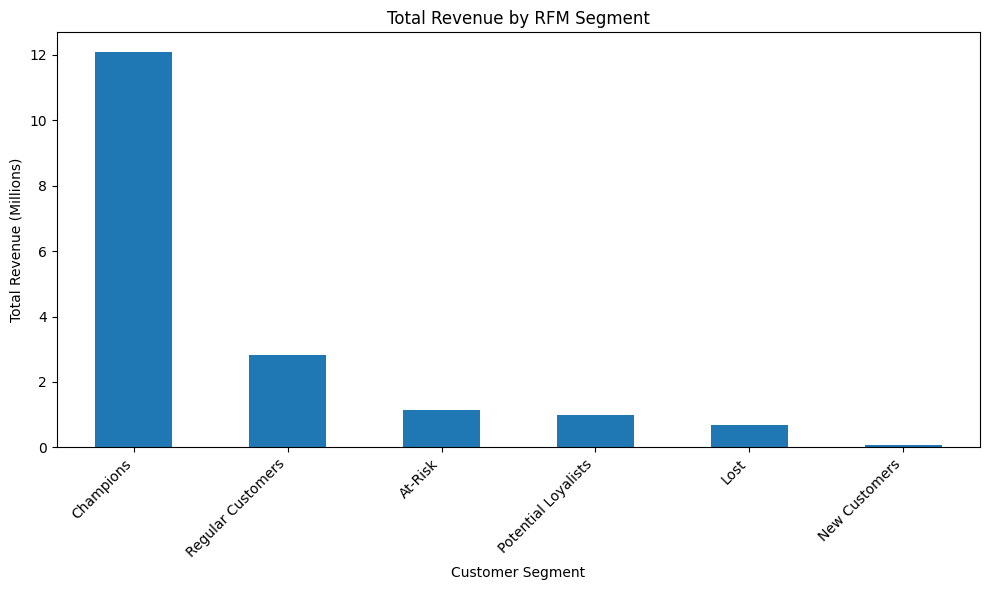

Chart saved to: ..\dashboards\rfm_revenue_by_segment.png


In [ ]:
# Make a chart for total revenue by RFM segment
segment_revenue_millions = segment_revenue / 1_000_000

output_path = Path("../dashboards/rfm_revenue_by_segment.png")

plt.figure(figsize=(10, 6))
segment_revenue_millions.plot(kind="bar")

plt.title("Total Revenue by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue (Millions)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(output_path, dpi=300)
plt.show()

print(f"Chart saved to: {output_path}")

In [ ]:
# Calculate total revenue by customer segment
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

# easier reading of revenue values
segment_revenue_formatted = segment_revenue.apply(lambda x: f"{x:,.2f}")

segment_revenue_formatted

Segment
Champions              12,087,432.74
Regular Customers       2,817,310.67
At-Risk                 1,127,231.17
Potential Loyalists       987,497.33
Lost                      668,139.90
New Customers              55,817.36
Name: Monetary, dtype: str

In [23]:
# Save the segment summary table

summary_output_path = Path("../dashboards/rfm_segment_summary.csv")

segment_summary.to_csv(summary_output_path)

print(f"Segment summary saved to: {summary_output_path}")

Segment summary saved to: ..\dashboards\rfm_segment_summary.csv


In [22]:
# Save the customer-level RFM segmentation results

rfm_output_path = Path("../dashboards/rfm_customer_segments.csv")

rfm.to_csv(rfm_output_path, index=False)

print(f"RFM customer segments saved to: {rfm_output_path}")

RFM customer segments saved to: ..\dashboards\rfm_customer_segments.csv


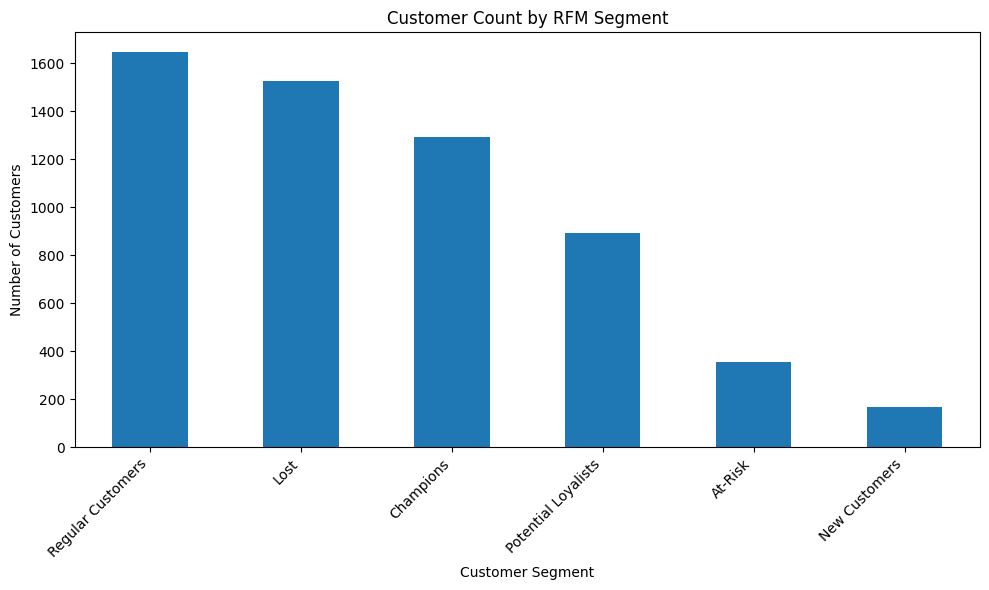

Chart saved to: ..\dashboards\rfm_segments.png


In [21]:
# Save the RFM segment chart to the dashboards folder

output_path = Path("../dashboards/rfm_segments.png")

plt.figure(figsize=(10, 6))
segment_counts.plot(kind="bar")

plt.title("Customer Count by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(output_path, dpi=300)
plt.show()

print(f"Chart saved to: {output_path}")

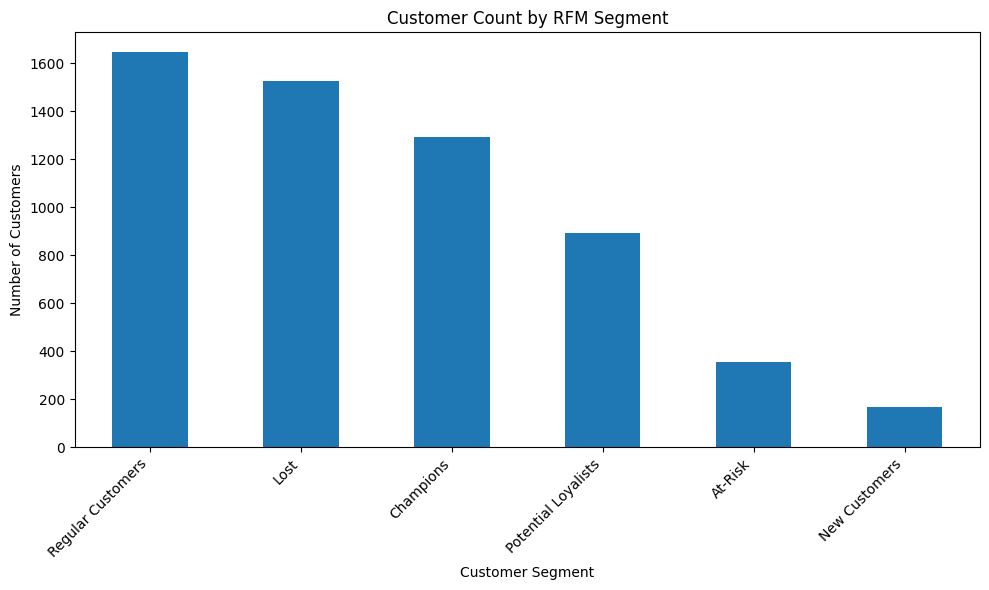

In [20]:
# Create a bar chart showing the number of customers in each segment

segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(10, 6))
segment_counts.plot(kind="bar")

plt.title("Customer Count by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [19]:
# Summarize customer behavior by segment

segment_summary = rfm.groupby("Segment").agg({
    "CustomerID": "count",
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)

segment_summary = segment_summary.rename(columns={
    "CustomerID": "Customer_Count",
    "Recency": "Avg_Recency",
    "Frequency": "Avg_Frequency",
    "Monetary": "Avg_Monetary"
})

segment_summary.sort_values("Customer_Count", ascending=False)

,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
Regular Customers,1647,187.54,4.40,1710.57
Lost,1526,458.75,1.25,437.84
Champions,1292,19.73,17.13,9355.60
Potential Loyalists,892,25.09,3.17,1107.06
At-Risk,354,343.77,7.57,3184.27
New Customers,167,29.55,1.00,334.24


In [17]:
# Count how many customers are in each segment

segment_counts = rfm["Segment"].value_counts()

segment_counts

Segment
Regular Customers      1647
Lost                   1526
Champions              1292
Potential Loyalists     892
At-Risk                 354
New Customers           167
Name: count, dtype: int64

In [16]:
# Assign each customer to a business-friendly RFM segment

def assign_segment(row):
    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Champions"
    elif row["R_Score"] >= 4 and row["F_Score"] >= 2:
        return "Potential Loyalists"
    elif row["R_Score"] <= 2 and row["F_Score"] >= 4:
        return "At-Risk"
    elif row["R_Score"] <= 2 and row["F_Score"] <= 2:
        return "Lost"
    elif row["R_Score"] >= 4 and row["F_Score"] == 1:
        return "New Customers"
    else:
        return "Regular Customers"

rfm["Segment"] = rfm.apply(assign_segment, axis=1)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment
0,12346.0,326,12,77556.46,2,5,5,255,12,At-Risk
1,12347.0,2,8,5633.32,5,4,5,545,14,Champions
2,12348.0,75,5,2019.40,3,4,4,344,11,Regular Customers
3,12349.0,19,4,4428.69,5,3,5,535,13,Potential Loyalists
4,12350.0,310,1,334.40,2,1,2,212,5,Lost
5,12351.0,375,1,300.93,2,1,2,212,5,Lost
6,12352.0,36,10,2849.84,4,5,4,454,13,Champions
7,12353.0,204,2,406.76,2,2,2,222,6,Lost
8,12354.0,232,1,1079.40,2,1,3,213,6,Lost
9,12355.0,214,2,947.61,2,2,3,223,7,Lost


In [14]:
# Create combined RFM score columns

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm["RFM_Total"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346.0,326,12,77556.46,2,5,5,255,12
1,12347.0,2,8,5633.32,5,4,5,545,14
2,12348.0,75,5,2019.40,3,4,4,344,11
3,12349.0,19,4,4428.69,5,3,5,535,13
4,12350.0,310,1,334.40,2,1,2,212,5


In [26]:
# Convert RFM score columns from categories into integers

rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment
0,12346.0,326,12,77556.46,2,5,5,255,12,At-Risk
1,12347.0,2,8,5633.32,5,4,5,545,14,Champions
2,12348.0,75,5,2019.40,3,4,4,344,11,Regular Customers
3,12349.0,19,4,4428.69,5,3,5,535,13,Potential Loyalists
4,12350.0,310,1,334.40,2,1,2,212,5,Lost


In [10]:
# Score each RFM metric from 1 to 5.
# For Recency, lower values are better, so recent customers get higher scores.
# For Frequency and Monetary, higher values are better.

rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346.0,326,12,77556.46,2,5,5
1,12347.0,2,8,5633.32,5,4,5
2,12348.0,75,5,2019.40,3,4,4
3,12349.0,19,4,4428.69,5,3,5
4,12350.0,310,1,334.40,2,1,2


In [9]:
# Check the size and summary statistics of the RFM table

print("RFM table shape:", rfm.shape)

rfm.describe()

RFM table shape: (5878, 4)


,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,3018.616737
std,209.338707,13.009406,14737.731040
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,348.762500
50%,96.000000,3.000000,898.915000
75%,380.000000,7.000000,2307.090000
max,739.000000,398.000000,608821.650000


In [ ]:
# See how many customers there are in the RFM table
rfm.shape

(5878, 4)

In [ ]:
# Creating the rfm table  
# Each row represents a customer based on their ID

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Revenue": "sum"
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

rfm.head() #first 5 rows 



,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,5633.32
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [ ]:
# This converts InvoiceDate from text into a datetime 
# Calculates recency of purchase

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Earliest purchase date:", df["InvoiceDate"].min())
print("Latest purchase date:", df["InvoiceDate"].max())

Earliest purchase date: 2009-12-01 07:45:00
Latest purchase date: 2011-12-09 12:50:00


In [ ]:
# Checking the size and column types

print(df.shape)
print(df.dtypes)

(805549, 9)
Invoice          int64
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
CustomerID         str
Country            str
Revenue        float64
dtype: object


In [ ]:
# Connect to the SQLite database and load the cleaned ver of the data

db_path = Path("../retail_project.db")

conn = sqlite3.connect(db_path)

df = pd.read_sql_query("""
    SELECT *
    FROM retail_clean;
""", conn)

conn.close()

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path